# Assignment 2: Groups and the GDL blueprint

In [5]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.fftpack import diff as psdiff
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR
import itertools

import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

## Exercise 1: Groups (1pt)

In this exercise, we will show the group axioms for important groups of matrices discussed in the lecture, namely the **Special Linear Group** (volume- and orientation-preserving matrices (det = 1)) and the **Orthogonal Group** (angle-preserving (orthogonal) matrices).

*Hint: You can assume associativity to be satisfied since it is a general property of matrix multiplication.*

### Exercise 1a: Special Linear Group (0.5pts)

Show thath $SL(d)=\{A \in \mathbb{R}^{d \times d} | \text{det}(A)=1\}$, with the operation being matrix multiplication, is a group.

** Solution **

### Show that $SL(d)$ is a group

Given

$$
SL(d)=\{A \in \mathbb{R}^{d \times d} \mid \det(A)=1\}.
$$

Group axioms are shown regarding the matrix multiplication:

- **Closure:** Are $A,B \in SL(d)$, the following applies

  $$
  \det(AB)=\det(A)\det(B)=1 \cdot 1=1.
  $$

  Therefore $AB \in SL(d)$.

- **Associativity:** This applies generally to matrix multiplication.

- **Neutral Element:** The identiy matrix $I_d$ fulfills

  $$
  I_dA=AI_d=A
  $$

  for all $A$, and so the following applies

  $$
  \det(I_d)=1.
  $$

  Therfore $I_d \in SL(d)$.

- **Inverse Elements:** For $A \in SL(d)$ the following applies $\det(A)=1 \neq 0$, therefore $A$ is invertible. Also the following applies

  $$
  \det(A^{-1})=\frac{1}{\det(A)}=1.
  $$

  Therefore $A^{-1}\in SL(d)$.

This satisfies all the group axioms, so  $SL(d)$ is a group.

### Exercise 1b: Ortghogonal Group (0.5pts)

Show that $O(d) = \left\{ A \in \mathbb{R}^{d \times d} : \langle Ax, Ay \rangle = \langle x, y \rangle \, \forall x, y \in \mathbb{R}^d \right\}$, with the operation being matrix multiplication, is a group.

** Solution **

### Show that $O(d)$ is a group

Given

$$
O(d)=\left\{ A \in \mathbb{R}^{d \times d} : \langle Ax, Ay \rangle = \langle x, y \rangle \text{ für alle } x,y \in \mathbb{R}^d \right\}.
$$

Group axioms are shown regarding the matrix multiplication:

- **Closure:** Are $A,B \in O(d)$, the following applies for all $x,y \in \mathbb{R}^d$:
  $$
  \langle ABx, ABy \rangle = \langle Bx, By \rangle = \langle x, y \rangle.
  $$
  Therefore $AB \in O(d)$.

- **Associativity:** his applies generally to matrix multiplication.

- **Neutral Element:** The identiy matrix $I_d$ fulfills
  $$
  \langle I_d x, I_d y \rangle = \langle x, y \rangle
  $$
  for all $x,y$. Therefore $I_d \in O(d)$.

- **Inverse Elements:** Being $A \in O(d)$ then $A$ is invertibel. For $x=Au$ and $y=Av$ the following applies
  $$
  \langle A^{-1}x, A^{-1}y \rangle = \langle u, v \rangle = \langle x, y \rangle.
  $$
  Therefore $A^{-1} \in O(d)$.

This satisfies all the group axioms, so $O(d)$ is a group.

## Exercise 2: The Regular Representation (1pt)

Let us now move onto how transformations induced by groups affect our data.
When a group $G$ acts on an underlying space $\Omega$, it induces a transformation on the signals living there.
Here, we will show that this induced action, the regular representation, is a well-defined linear representation.

Let $\mathcal{X}(\Omega) = \{f: \Omega \rightarrow \mathcal{C}\}$ be the space of signals, where $\mathcal{C}$ is a vector space, and let $G$ be a group acting on $\Omega$.

Prove that for $u \in \Omega$ and $g \in G$, the regular representation defined by $(\rho(g)x)(u) = x(g^{-1}u)$ is a linear representation.

** Solution **

# Regular representation is a linear representation

Let

$$
\mathcal{X}(\Omega)=\{f:\Omega \to \mathcal{C}\},
$$

where $\mathcal{C}$ is a vector space and $G$ acts on $\Omega$. Define

$$
(\rho(g)x)(u)=x(g^{-1}u).
$$

Show that $\rho$ is a linear representation.

- **Well-definedness:** Since $g^{-1}u \in \Omega$, $x(g^{-1}u)$ is well-defined, so $\rho(g)x \in \mathcal{X}(\Omega)$.

- **Linearity:** For $x,y \in \mathcal{X}(\Omega)$ and scalars $a,b$,
  $$
  (\rho(g)(ax+by))(u)=(ax+by)(g^{-1}u)=a\,x(g^{-1}u)+b\,y(g^{-1}u).
  $$
  Hence $\rho(g)(ax+by)=a\rho(g)x+b\rho(g)y$.

- **Group property:**
  $$
  (\rho(gh)x)(u)=x((gh)^{-1}u)=x(h^{-1}g^{-1}u).
  $$
  Also
  $$
  (\rho(g)\rho(h)x)(u)=x(h^{-1}g^{-1}u).
  $$
  Thus $\rho(gh)=\rho(g)\rho(h)$.

- **Identity:**
  $$
  (\rho(e)x)(u)=x(e^{-1}u)=x(u),
  $$
  so $\rho(e)=\mathrm{id}$.

Therefore, $\rho$ is a linear representation.

## Exercise 3: Group Averaging (1pt)

Another technique discussed in the lecture is group averaging, where we aggregate a function's output over all possible group transformations, i.e. over the whole orbit.
In this exercise, we will verify a core mathematical property of this operation: if a linear function is already invariant to a finite group $G$, applying the group average to the input leaves the function's output unchanged.

In more mathematical terms:

Let $f: \mathcal{X} \rightarrow \mathbb{R}$ be linear $G$-invariant ($G$ finite group). Then $f(x) = f(S_G x)$, i.e. $f$ is also invariant to the group average.

Prove this!

** Solution **

# Group Averaging Invariance

Let $f: \mathcal{X} \to \mathbb{R}$ be a linear and $G$-invariant function, where $G$ is a finite group. Define the group average by

$$
S_G x = \frac{1}{|G|} \sum_{g \in G} g x.
$$

Prove that

$$
f(x) = f(S_G x).
$$

## Proof

Compute:

$$
f(S_G x) = f\left(\frac{1}{|G|} \sum_{g \in G} g x \right).
$$

Using linearity of $f$, obtain:

$$
= \frac{1}{|G|} \sum_{g \in G} f(gx).
$$

Since $f$ is $G$-invariant, it is for all $g \in G$:

$$
f(gx) = f(x).
$$

Thus:

$$
= \frac{1}{|G|} \sum_{g \in G} f(x).
$$

Since there are $|G|$ identical terms, there is:

$$
= \frac{1}{|G|} \cdot |G| \cdot f(x) = f(x).
$$

## Conclusion

Therefore,

$$
f(S_G x) = f(x),
$$

so $f$ is invariant under the group averaging operator.

## Exercise 4: Nonlinear Equivariance (1pt)

To build powerful deep neural networks, linear layers alone are not enough. Even the early formulations of the universal approximation theorem included non-linear activation functions as a necessity.
However, when designing architectures with our GDL blueprint in mind, we must ensure that applying these nonlinearities does not break the symmetries we carefully try to bake in.

We will therefore show that an element-wise nonlinearity (e.g., a ReLU or any other activation function used in modern deep learning) applied to a linear, $G$-equivariant function results in a composition that is perfectly $G$-equivariant.

Let $\mathcal{X}(\Omega)$ be a space of signals and $f: \mathcal{X} \rightarrow \mathcal{X}$ a linear, $G$-equivariant function, where equivariance is understood with respect to the linear representation $\rho$ for signals as in Exercise 2. Furthermore, let $\sigma: \mathcal{X} \rightarrow \mathcal{X}$ be an element-wise nonlinearity: $(\sigma x)(u) = \sigma(x(u))$.

Prove that $\sigma \circ f$ is nonlinear $G$-equivariant!

** Solution **

# Nonlinear Equivariance

Let $\mathcal{X}(\Omega)$ be a space of signals and $f: \mathcal{X} \to \mathcal{X}$ a linear, $G$-equivariant function. Let $\sigma: \mathcal{X} \to \mathcal{X}$ be an element-wise nonlinearity defined by

$$
(\sigma x)(u) = \sigma(x(u)).
$$

Show that $\sigma \circ f$ is $G$-equivariant, i.e.

$$
(\sigma \circ f)(\rho(g)x) = \rho(g)(\sigma \circ f)(x).
$$

## Proof

For $u \in \Omega$, we compute:

$$
((\sigma \circ f)(\rho(g)x))(u)
= \sigma(f(\rho(g)x)(u)).
$$

Since $f$ is $G$-equivariant, we have:

$$
= \sigma((\rho(g)f(x))(u)).
$$

Using the definition of the representation:

$$
= \sigma(f(x)(g^{-1}u)).
$$

Since $\sigma$ acts element-wise:

$$
= (\sigma(f(x)))(g^{-1}u).
$$

Using again the definition of $\rho$:

$$
= (\rho(g)(\sigma(f(x))))(u).
$$

Thus,

$$
(\sigma \circ f)(\rho(g)x) = \rho(g)(\sigma \circ f)(x).
$$

## Conclusion

Therefore, $\sigma \circ f$ is $G$-equivariant.

## Exercise 5: Korteweg-de Vries (KdV) Equation (4pts)

In this exercise, we investigate how symmetries impact the generalization performance of modern deep learning models applied to physical systems governed by partial differential equations (PDEs). Specifically, we will focus on the **Korteweg-de Vries (KdV)** equation and its Lie point symmetries.
We will prove them, implement symmetry transformations, verify numerically that they preserve solutions, and then use them for physics-consistent data augmentation.

As a reminder, the KdV equation reads:

$$u_t + uu_x + u_{xxx} = 0,$$

where $uu_x$ is a nonlinear convection term and $u_{xxx}$ is a dispersive term.

This PDE exhibits the following Lie point symmetries:

- $g_1(\epsilon)u = u(x, t-\epsilon) \rightarrow$ time translation
- $g_2(\epsilon)u = u(x-\epsilon, t) \rightarrow$ space translation
- $g_3(\epsilon)u = u(x-\epsilon t, t)+\epsilon \rightarrow$ Galilean boost
- $g_4(\epsilon)u = e^{-2\epsilon}u(e^{-\epsilon}x, e^{-3\epsilon}t) \rightarrow$ scaling

### Exercise 5a: Proving invariance (1pt)

Prove, that the KdV equation is invariant under (1) $g_2(\epsilon)u$ and (2) $g_3(\epsilon)u$.

*Hint: Show that if $u$ is a solution to KdV, then $g(\epsilon)u$ also is one.*

** Solution **


# Invariance of the KdV equation

The KdV equation is given by

$$
u_t + u u_x + u_{xxx} = 0.
$$

Show that it is invariant under (1) space translation and (2) Galilean transformation.

## Space translation

Let

$$
v(x,t) = u(x-\epsilon, t).
$$

Define $\xi = x-\epsilon$. Then:

$$
v_t = u_t(\xi,t), \quad v_x = u_x(\xi,t), \quad v_{xxx} = u_{xxx}(\xi,t).
$$

Substituting into the KdV equation gives:

$$
v_t + v v_x + v_{xxx}
= u_t + u u_x + u_{xxx} = 0.
$$

Thus, the KdV equation is invariant under space translation.

## Galilean transformation

Let

$$
v(x,t) = u(x-\epsilon t, t) + \epsilon.
$$

Define $\xi = x-\epsilon t$. Then:

$$
v_t = u_t - \epsilon u_x,
$$

$$
v_x = u_x, \quad v_{xxx} = u_{xxx}.
$$

The nonlinear term becomes:

$$
v v_x = (u+\epsilon)u_x = u u_x + \epsilon u_x.
$$

Substituting gives:

$$
v_t + v v_x + v_{xxx}
= (u_t - \epsilon u_x) + (u u_x + \epsilon u_x) + u_{xxx}.
$$

The terms cancel:

$$
-\epsilon u_x + \epsilon u_x = 0,
$$

so we obtain:

$$
= u_t + u u_x + u_{xxx} = 0.
$$

## Conclusion

The KdV equation is invariant under both transformations.

### Exercise 5b: Generate a Trajectory (1pt)

When solving PDEs, we have to provide a starting point, i.e. Initial Conditions (ICs).
For the following examples, we want to sample ICs from a distribution over truncated Fourier series with random coefficients $\{A_k, \ell_k, \phi_k\}_k$ as

$$
u_0(x) = \sum_{k=1}^{K} A_k \sin(2\pi \ell_k x/L + \phi_k),
$$

where $N$ is the number of Fourier modes, $L$ is the domain length.

- Generate ICs for $K=10$, $L=128$, and the parameters for each frequency $k$ sampled independently according to the following distributions:
    * **Amplitudes:** $A_k \sim \mathcal{U}(-0.5, 0.5)$ 
    * **Phases:** $\phi_k \sim \mathcal{U}(0, 2\pi)$
    * **Wavenumbers:** $\ell_k \sim \mathcal{U}\{1, 3\}$ (sampled uniformly as discrete integers)
- Simulate the trajectory over the time intervval $t \in [0,100]$.
- Plot your result.

We are providing a suitable numerical solver aswell as some plotting utilities below.

*Hint: In order to keep the numerics stable and obtain a smooth looking solution, use 200 timesteps and 256 spatial discretization points. Because we are using periodic boundary conditions, the spatial grid should not include the endpoint $L$ (since $u(L, t) = u(0, t)$). You can define a suitable grid by e.g. ``x = np.linspace(0, L * (1 - 1/N_space), N_space)``*.


In [6]:
# DON'T MODIFY THIS CELL
def kdv_pseudospectral(t: float, u: np.ndarray, L: float) -> np.ndarray:
    """
    Computes spatial derivatives for the KdV equation, using a pseudospectral method, discretization in x.
    Args:
        t (float): time point
        u (np.ndarray): 1D input field
        L (float): length of the spatial domain
    Returns:
        np.ndarray: reconstructed pseudospectral time derivative
    """
    ux = psdiff(u, order=1, period=L)
    uxxx = psdiff(u, order=3, period=L)
    ut = -u*ux - uxxx
    return ut

def solve(t: np.ndarray, u0: np.ndarray, L: float, tol: float = 1e-8) -> np.ndarray:
    """Solves the KdV equation using a pseudospectral method and an ODE solver.
    Args:
        t (np.ndarray): 1D array of time points to evaluate the solution at
        u0 (np.ndarray): 1D array of initial conditions for the spatial field
        L (float): length of the spatial domain
        tol (float): tolerance for the ODE solver
    Returns:
        np.ndarray: solution array
    """
    sol = solve_ivp(fun=kdv_pseudospectral, 
                                t_span=[t[0], t[-1]], 
                                y0=u0, 
                                method='Radau',
                                t_eval=t, 
                                args=(L,), 
                                atol=tol, 
                                rtol=tol)
    return sol.y

def plot_single_solution(x: np.ndarray, t: np.ndarray, sol: np.ndarray):
    """
    Plots a spatiotemporal heatmap of the Korteweg-de Vries (KdV) equation solution.
    
    This function visualizes how the spatial signal u(x) evolves over time t by 
    creating a 2D color plot (heatmap) where the x-axis represents the spatial 
    domain and the y-axis represents the temporal domain.

    Args:
        x (np.ndarray): 1D array of spatial grid points of shape (N_space,).
        t (np.ndarray): 1D array of time points of shape (N_time,).
        sol (np.ndarray): 2D array containing the solution trajectory with 
            shape (N_space, N_time).
            
    Returns:
        None: Displays the generated matplotlib figure.
    """
    plt.figure(figsize=(8, 4))
    
    X, T = np.meshgrid(x, t)
    heatmap = plt.pcolormesh(X, T, sol.T, cmap='RdBu_r', shading='gouraud')
    
    plt.title('KdV Trajectory', fontsize=16)
    plt.xlabel('x', fontsize=14)
    plt.ylabel('t', fontsize=14)
    
    cbar = plt.colorbar(heatmap)
    cbar.set_label('u(x,t)', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()

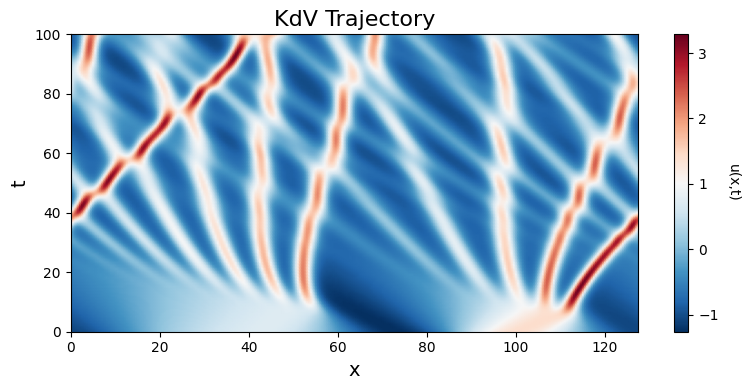

In [ ]:
# COMPLETE THE FUNCTION AND GENERATE ICs & PLOT SOLUTION
def generate_initial_conditions(x: np.ndarray, K: int, L: float) -> np.ndarray:
    """Generates a random initial condition for the KdV equation as a sum of sine waves.
    Args:
        x (np.ndarray): 1D array of spatial grid points
        K (int): number of sine wave components to sum
        L (float): length of the spatial domain
    Returns:
        np.ndarray: 1D array of initial conditions for the spatial field
    """
    # YOUR CODE HERE

    # sample parameters
    A = np.random.uniform(-0.5, 0.5, size=K) # amplitudes
    phi = np.random.uniform(0, 2*np.pi, size=K) # phases
    ell = np.random.randint(1, 4, size=K) # wavenumbers {1,2,3}
    
    # initialize u0
    u0 = np.zeros_like(x)
    
    # build Fourier sum
    for k in range(K):
        u0 += A[k] * np.sin(2 * np.pi * ell[k] * x / L + phi[k])
    
    return u0

# YOUR CODE HERE
# generate spatial grid and initial conditions
N_space = 256
L = 128
K = 10

x = np.linspace(0, L * (1 - 1 / N_space), N_space)
u0 = generate_initial_conditions(x, K, L)


# generate time grid
N_time = 200
t = np.linspace(0, 100, N_time)


# compute solution
sol = solve(t, u0, L)


# plot trajectory
plot_single_solution(x, t, sol)

### Exercise 5c: Implement transformations (1pt)

- Implement the space translation and the Galilean boost.
- Plot your transformed trajectories with the given plotting function.
- Show (this time numerically) that those are indeed solutions to the PDE.


In order to allow sub-pixel level data shifts, we can use the Fourier shift theorem, where a shift is obtained via Fourier transform, exponentiation in the Fourier space and backtransform:

$$f(x - \epsilon) = \mathcal{F}^{-1}\left(e^{-2\pi i\xi\epsilon}\mathcal{F}(x)\right).$$

Here $\xi$ are the frequencies in the Fourier space and $\epsilon$ is the shift parameter, which is the (normalized) parameter of the respective Lie point symmetries.

*Hint: To show numerically that your transformed trajectories are solutions, compare them to a trajectory which is obtained by only transforming the first timestep and then solving with the numerical solver.*

In [8]:
# DON'T MODIFY THIS CELL
def fourier_shift(u: np.ndarray, eps: float | np.ndarray = 0.0, dim: int = -1) -> np.ndarray:
    """Shifts a signal in the Fourier domain using the Shift Theorem.
    Args:
        u (np.ndarray): The input signal or trajectory to be shifted.
        eps (float | np.ndarray): The shift magnitude. Can be a scalar for a 
            global shift or an array for vectorized/batch shifts.
        dim (int): The axis along which to apply the shift. Defaults to -1 (space).
    Returns:
        np.ndarray: The shifted signal in the original physical domain.
    """
    n = u.shape[dim]
    u_hat = np.fft.rfft(u, axis=dim, norm='ortho')
    # fourier modes
    omega = np.arange(n // 2 + 1)
    if n % 2 == 0:
        omega[-1] = 0
    # reshaping omega to be broadcastable with u_hat for vectorized shifts
    target_shape = [1] * u.ndim
    target_shape[dim] = -1
    omega = omega.reshape(target_shape)
    # applying shift according to the shift theorem
    fs = np.exp(-2 * np.pi * 1j * omega * eps)   
    return np.fft.irfft(fs * u_hat, n=n, axis=dim, norm='ortho')


def plot_original_vs_transformed(
    x: np.ndarray, 
    t: np.ndarray, 
    original: np.ndarray, 
    space_translated: np.ndarray, 
    gallilean_boosted: np.ndarray
):
    """Visualizes the original KdV solution alongside its symmetry-transformed versions.
    Args:
        x (np.ndarray): 1D array of spatial grid points.
        t (np.ndarray): 1D array of time points.
        original (np.ndarray): The baseline KdV solution trajectory.
        space_translated (np.ndarray): The trajectory after applying g2(eps).
        gallilean_boosted (np.ndarray): The trajectory after applying g3(eps).
    Returns:
        None: Displays a 1x3 grid of spatiotemporal heatmaps.
    """
    # calculate the global minimum and maximum values across the remaining datasets.
    all_data = [original, space_translated, gallilean_boosted]
    vmin = np.nanmin(all_data)
    vmax = np.nanmax(all_data)
    
    # create a 1x3 grid of subplots. A wide figure size works best here.
    fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
    
    # create the meshgrid where X goes across (columns) and T goes up (rows)
    X, T = np.meshgrid(x, t)
    
    # dictionary to cleanly loop through the data and axes (axs is now a 1D array)
    plots = {
        "Original Solution": (axs[0], original),
        "Space Translated": (axs[1], space_translated),
        "Galilean Boosted": (axs[2], gallilean_boosted)
    }
    
    for title, (ax, data) in plots.items():
        # add vmin and vmax to lock the color scale across all 3 plots
        heatmap = ax.pcolormesh(X, T, data.T, cmap="RdBu_r", shading="gouraud", vmin=vmin, vmax=vmax)
        
        ax.set_title(title, fontsize=15, fontweight="bold")
        
        # every subplot gets an X-axis label
        ax.set_xlabel("Space (x)", fontsize=13)
        
        # only the far-left subplot gets the Y-axis label to keep the layout clean
        if ax == axs[0]:
            ax.set_ylabel("Time (t)", fontsize=13)
            
    # add one global colorbar outside the loop.
    # fraction and pad are tweaked slightly to fit the wider 1x3 aspect ratio
    cbar = fig.colorbar(heatmap, ax=axs.ravel().tolist(), fraction=0.02, pad=0.02)
    cbar.set_label("Amplitude", rotation=270, labelpad=15)
            
    plt.suptitle("Lie Point Symmetries of the KdV Equation", fontsize=18, y=1.05)
    plt.show()

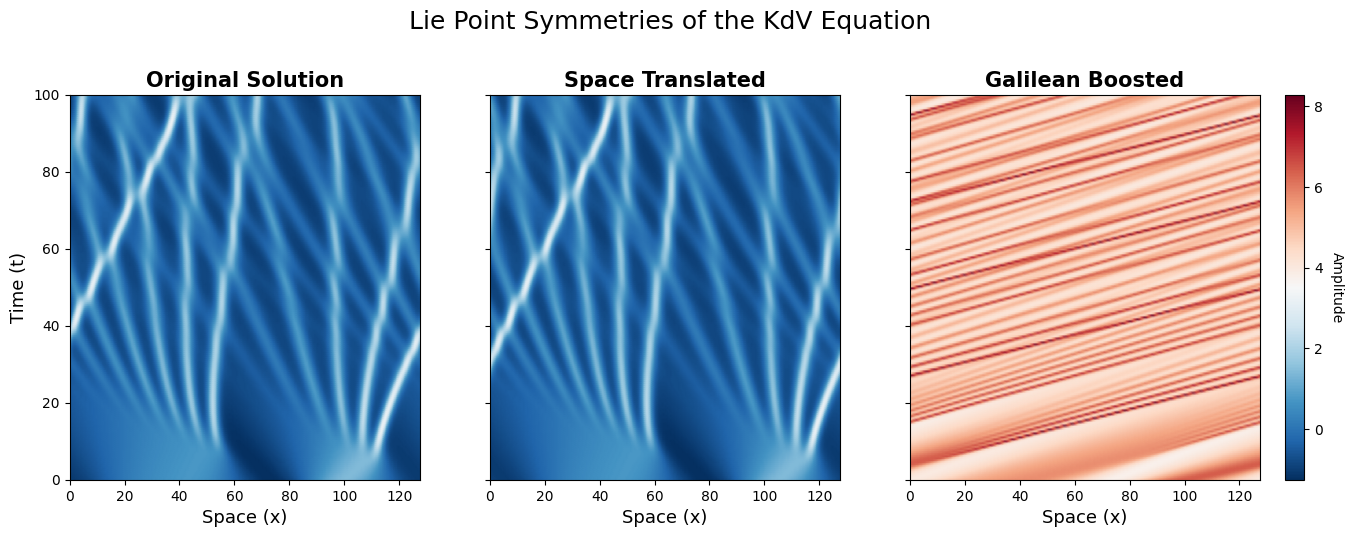

In [ ]:
# COMPLETE THE FUNCTIONS AND APPLY THEM & PLOT
def space_translation(u: np.ndarray, eps: float, L: float) -> np.ndarray:
    """Applies a space translation Lie point symmetry to a KdV solution u_new(x, t) = u(x - eps, t).
    Args:
        u (np.ndarray): 2D array of the spatiotemporal solution field (shape: N_space x N_time).
        eps (float): The translation parameter representing the shift distance.
        L (float): Length of the periodic spatial domain.   
    Returns:
        np.ndarray: 2D array of the transformed solution.
    """
    # YOUR CODE HERE

    # normalize shift (important!)
    eps_norm = eps / L
    
    # shift along spatial dimension (axis 0)
    u_shifted = fourier_shift(u, eps_norm, dim=0)
    
    return u_shifted


def gallilean_boost(t: np.ndarray, u: np.ndarray, eps: float, L: float) -> np.ndarray:
    """Applies the Galilean boost Lie point symmetry: g3(ε)u = u(x - εt, t) + ε.
    Args:
        t (np.ndarray): 1D array of time points of shape (N_time,).
        u (np.ndarray): 2D array of the spatiotemporal solution field 
            with shape (N_space, N_time).
        eps (float): The boost parameter representing the relative velocity.
        L (float): Total length of the periodic spatial domain.
    Returns:
        np.ndarray: 2D array of the boosted solution.
    """    
    # YOUR CODE HERE

    # time-dependent shifts
    eps_t = eps * t / L   # normalize
    
    # reshape for broadcasting (1, N_time)
    eps_t = eps_t.reshape(1, -1)
    
    # apply shift along spatial dimension
    u_shifted = fourier_shift(u, eps_t, dim=0)
    
    # add constant offset
    u_boosted = u_shifted + eps
    
    return u_boosted

# # YOUR CODE HERE
# translate the trajectory from above using 1. the space translation and 2. the Galilean boost, then plot all 3 trajectories side by side for comparison.

# APPLY TRANSFORMATIONS
eps = 5.0  # choose some shift value

# original solution (from previous exercise)
original = sol

# transformed trajectories
space_translated = space_translation(original, eps, L)
gallilean_boosted = gallilean_boost(t, original, eps, L)

# plot comparison
plot_original_vs_transformed(x, t, original, space_translated, gallilean_boosted)

In [10]:
# DON'T MODIFY THIS CELL
def rel_l2_error_trajectory(traj1: np.ndarray, traj2: np.ndarray) -> float:
    """Computes the relative L2 error between two KdV trajectories.
    Args:
        traj1 (np.ndarray): First trajectory (shape: N_space x N_time).
        traj2 (np.ndarray): Second trajectory (shape: N_space x N_time).
    Returns:
        float: The relative L2 error computed as ||traj1 - traj2||_2 / ||traj1||_2.
    """
    numerator = np.linalg.norm(traj1 - traj2)
    denominator = np.linalg.norm(traj1)
    rel_error = numerator / denominator if denominator != 0 else np.inf
    return rel_error

In [ ]:
# show that the transformations are actually solutions of the KdV equation by comparing them against solver outputs
# YOUR CODE HERE

eps = 5.0

# SPACE TRANSLATION CHECK
# transform initial condition
u0_shifted = space_translation(u0.reshape(-1,1), eps, L).flatten()

# solve PDE with transformed IC
sol_shifted = solve(t, u0_shifted, L)

# compare with transformed trajectory
error_space = rel_l2_error_trajectory(space_translated, sol_shifted)

print("Relative L2 error (space translation):", error_space)

# GALILEAN BOOST CHECK
# for Galilean: at t=0 → shift = 0, only +eps
u0_gal = u0 + eps

# solve PDE
sol_gal = solve(t, u0_gal, L)

# compare
error_gal = rel_l2_error_trajectory(gallilean_boosted, sol_gal)

print("Relative L2 error (Galilean boost):", error_gal)

Relative L2 error (space translation): 4.831199501300331e-11
Relative L2 error (Galilean boost): 1.9558091769644596e-05


### Exercise 5d: Neural Network training (1pt)

We now want put our Lie point symmetry data augmentations into action and show to showcase their effectivity. We will be trainig a Fourier Neural Operator (FNO) (the architecture is not the focus of this exercise but if you are interested, take a look at the [paper](https://arxiv.org/abs/2010.08895)).

We want to compare the validation error of two models on the same **validation set**:

1. **Model trained with base dataset (no augmentations)**: train only on base trajectories.
2. **Model trained with augmented dataset**: train on base trajectories + symmetry-transformed trajectories (space translation + Galilean boost).

Again, we provide some helper functions below.

In [12]:
# DON'T MODIFY THIS CELL
def trajectories_to_dataset(
    trajectories: list[np.ndarray],
    bundle_size: int = 4,
    stride: int = 1,
) -> TensorDataset:
    """Converts raw spatiotemporal trajectories into a supervised learning dataset.
    Args:
        trajectories (list[np.ndarray]): A list of 2D arrays, each with shape 
            (N_space, N_time), representing simulated KdV evolutions.
        bundle_size (int): The number of historical time steps used as input 
            features for the model. Defaults to 4.
        stride (int): The step size between sliding windows. Defaults to 1.
    Returns:
        TensorDataset: A dataset for model training.
    """
    X_list, y_list = [], []

    for u_tx in trajectories:
        u_tx = u_tx.T  # [time, space] -> [space, time]
        n_time = u_tx.shape[0]
        for i in range(0, n_time - bundle_size, stride):
            history = u_tx[i:i + bundle_size]  # [bundle, space]
            target = u_tx[i + bundle_size]     # [space]
            X_list.append(history.T)           # [space, bundle]
            y_list.append(target)

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.stack(y_list, axis=0).astype(np.float32)

    return TensorDataset(torch.from_numpy(X), torch.from_numpy(y))

As a first step, finish the code in the cell below to generate the datasets. Use the function ``trajectories_to_dataset`` above to generate the datasets from lists of trajectories.

In [13]:
# FINISH THE MISSING PARTS OF THE CELL
# generate base training and validation trajectories (nothing to do here)
K = 10
L = 128
N_grid_space = 256
T = 10
n_grid_time = 20
bundle_size = 4
stride = 1

n_train_base = 32
n_val = 16

x_train_grid = np.linspace(0.0, L * (1.0 - 1.0 / N_grid_space), N_grid_space)
t_train_grid = np.linspace(0.0, T, n_grid_time)

train_base_trajs = []
val_trajs = []
train_augmentations_only = []

# generate augmented trajectories
# YOUR CODE HERE

# generate augmented trajectories

eps_space = 5.0
eps_gal = 1.0

# training data
for _ in range(n_train_base):
    # sample IC
    u0 = generate_initial_conditions(x_train_grid, K, L)
    
    # solve PDE
    sol = solve(t_train_grid, u0, L)
    
    train_base_trajs.append(sol)
    
    # augmentations
    sol_space = space_translation(sol, eps_space, L)
    sol_gal = gallilean_boost(t_train_grid, sol, eps_gal, L)
    
    train_augmentations_only.append(sol_space)
    train_augmentations_only.append(sol_gal)


# validation data (NO augmentation!)
for _ in range(n_val):
    u0 = generate_initial_conditions(x_train_grid, K, L)
    sol = solve(t_train_grid, u0, L)
    val_trajs.append(sol)


# example code to process lists of trajectories and print dataset sizes. (nothing to change here)
train_augmented_trajs = train_base_trajs + train_augmentations_only
trainset = trajectories_to_dataset(
    train_base_trajs, bundle_size=bundle_size, stride=stride
)
trainset_aug = trajectories_to_dataset(
    train_augmented_trajs, bundle_size=bundle_size, stride=stride
)
valset = trajectories_to_dataset(
    val_trajs, bundle_size=bundle_size, stride=stride
)

print("Dataset sizes:")
print("  train (no aug):", len(trainset))
print("  train (aug):   ", len(trainset_aug))
print("  validation:    ", len(valset))

Dataset sizes:
  train (no aug): 512
  train (aug):    1536
  validation:     256


In [14]:
# DON'T MODIFY THIS CELL
def select_device() -> torch.device:
    """Prefer CUDA, then MPS, else CPU."""
    if torch.cuda.is_available():
        try:
            x = torch.randn(16, device="cuda")
            _ = torch.fft.rfft(x)
            return torch.device("cuda")
        except Exception as e:
            print(f"CUDA reported available but failed runtime check: {e}. Falling back.")

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        try:
            x = torch.randn(16, device="mps")
            _ = x.sum().item()
            return torch.device("mps")
        except Exception as e:
            print(f"MPS reported available but failed runtime check: {e}. Falling back.")

    return torch.device("cpu")


class SpectralConv1d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, modes: int):
        super().__init__()
        self.modes = modes
        scale = 1.0 / (in_channels * out_channels)
        self.weight = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes, dtype=torch.cfloat)
        )
        self.out_channels = out_channels

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, C, N]
        B, _, N = x.shape
        x_ft = torch.fft.rfft(x, dim=-1)
        out_ft = torch.zeros(B, self.out_channels, x_ft.shape[-1], device=x.device, dtype=torch.cfloat)
        m = min(self.modes, x_ft.shape[-1])
        out_ft[:, :, :m] = torch.einsum("bcm,com->bom", x_ft[:, :, :m], self.weight[:, :, :m])
        return torch.fft.irfft(out_ft, n=N, dim=-1)


class SimpleFNO1d(nn.Module):
    def __init__(self, in_dim: int, width: int = 32, modes: int = 12, n_layers: int = 3):
        super().__init__()
        self.fc0 = nn.Linear(in_dim, width)
        self.sconvs = nn.ModuleList([SpectralConv1d(width, width, modes) for _ in range(n_layers)])
        self.ws = nn.ModuleList([nn.Conv1d(width, width, kernel_size=1) for _ in range(n_layers)])
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, N, in_dim]
        x = self.fc0(x)
        x = x.permute(0, 2, 1)
        for sc, w in zip(self.sconvs, self.ws):
            x = F.gelu(sc(x) + w(x))
        x = x.permute(0, 2, 1)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x).squeeze(-1)
        return x


def evaluate_mse(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    model.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = F.mse_loss(pred, yb, reduction="sum")
            total += loss.item()
            count += yb.shape[0]
    return total / count

As a next step, please complete the template function for model training below. We can train with a standard MSE error.

In [15]:
# FINISH THE FUNCTION BELOW
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    total_steps: int = 2000,
    eval_every: int = 100,
    lr: float = 2e-3,
) -> tuple[np.ndarray, np.ndarray]:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=1e-6)
    
    train_curve, val_curve = [], []
    train_iter = itertools.cycle(train_loader)
    
    model.train()
    running_loss = 0.0

    for step in range(1, total_steps + 1):
        xb, yb = next(train_iter)
        xb, yb = xb.to(device), yb.to(device)
        
        # # YOUR CODE HERE
        
        # TRAINING STEP
        optimizer.zero_grad()
        
        pred = model(xb)
        loss = F.mse_loss(pred, yb)
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        running_loss += loss.item()

        if step % eval_every == 0:
            avg_train_loss = running_loss / eval_every
            val_mse = evaluate_mse(model, val_loader, device)
            
            # Get current LR for logging (optional but helpful)
            current_lr = optimizer.param_groups[0]['lr']
            
            train_curve.append(avg_train_loss)
            val_curve.append(val_mse)
            
            print(f"Step {step:04d}/{total_steps} | LR: {current_lr:.2e} | train MSE: {avg_train_loss:.4e} | val MSE: {val_mse:.4e}")
            
            running_loss = 0.0
            model.train()

    return np.array(train_curve), np.array(val_curve)

The cell below should be finished and work nicely with the hyperparameters. But feel free to try out stuff and experiment a bit:)

Using device: cpu
Training model without augmentation...
Step 0050/1000 | LR: 1.99e-03 | train MSE: 9.8045e-02 | val MSE: 7.2605e-01
Step 0100/1000 | LR: 1.95e-03 | train MSE: 9.0550e-03 | val MSE: 2.4263e-01
Step 0150/1000 | LR: 1.89e-03 | train MSE: 2.9031e-03 | val MSE: 1.2635e-01
Step 0200/1000 | LR: 1.81e-03 | train MSE: 1.5836e-03 | val MSE: 9.6974e-02
Step 0250/1000 | LR: 1.71e-03 | train MSE: 1.1456e-03 | val MSE: 8.7411e-02
Step 0300/1000 | LR: 1.59e-03 | train MSE: 9.0215e-04 | val MSE: 8.1213e-02
Step 0350/1000 | LR: 1.45e-03 | train MSE: 7.1879e-04 | val MSE: 7.0180e-02
Step 0400/1000 | LR: 1.31e-03 | train MSE: 5.9957e-04 | val MSE: 6.6439e-02
Step 0450/1000 | LR: 1.16e-03 | train MSE: 5.1570e-04 | val MSE: 6.1323e-02
Step 0500/1000 | LR: 1.00e-03 | train MSE: 4.7244e-04 | val MSE: 5.8937e-02
Step 0550/1000 | LR: 8.44e-04 | train MSE: 4.3765e-04 | val MSE: 5.5653e-02
Step 0600/1000 | LR: 6.92e-04 | train MSE: 3.8502e-04 | val MSE: 5.3217e-02
Step 0650/1000 | LR: 5.47e-04 |

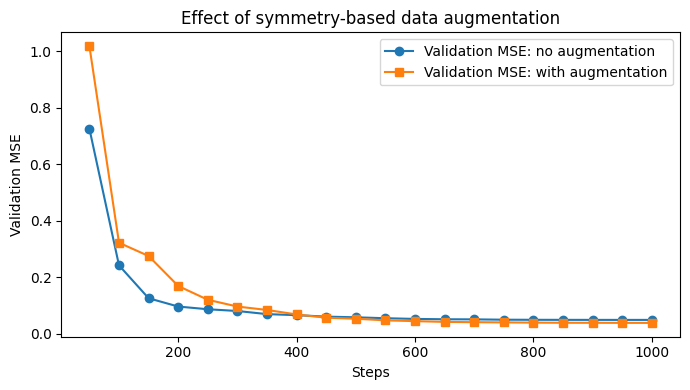

In [16]:
# NOTHING TO DO HERE BUT FEEL FREE TO EXPERIMENT
batch_size = 64
train_base_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
train_aug_loader = DataLoader(trainset_aug, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)

device = select_device()
print(f"Using device: {device}")

in_dim = bundle_size
model_noaug = SimpleFNO1d(in_dim=in_dim, width=32, modes=12, n_layers=3).to(device)
model_aug = SimpleFNO1d(in_dim=in_dim, width=32, modes=12, n_layers=3).to(device)

total_steps = 1000
eval_every = 50
print("Training model without augmentation...")
train_noaug, val_noaug = train_model(model_noaug, train_base_loader, val_loader, device, total_steps=total_steps, eval_every=eval_every)
print("Training model with augmentation...")
train_aug, val_aug = train_model(model_aug, train_aug_loader, val_loader, device, total_steps=total_steps, eval_every=eval_every)
print("\nFinal validation MSE (no augmentation):", float(val_noaug[-1]))
print("Final validation MSE (with augmentation):", float(val_aug[-1]))
print("Relative improvement (%):", float((val_noaug[-1] - val_aug[-1]) / val_noaug[-1] * 100.0))

steps_axes = np.arange(eval_every, total_steps + 1, eval_every)
plt.figure(figsize=(7, 4))
plt.plot(steps_axes, val_noaug, "o-", label="Validation MSE: no augmentation")
plt.plot(steps_axes, val_aug, "s-", label="Validation MSE: with augmentation")
plt.xlabel("Steps")
plt.ylabel("Validation MSE")
plt.title("Effect of symmetry-based data augmentation")
plt.legend()
plt.tight_layout()
plt.show()